# BBC 新闻：词性识别与命名实体识别准备

## Goal

1. 读取并展示 `bbc_news.csv`
2. 导入并验证 NLTK、spaCy
3. 为后续词性识别（POS）和命名实体识别（NER）做好准备

## Setup / Imports

第三方库统一放在顶部，方便查看当前 Notebook 使用的依赖。

In [1]:
# Python 标准库：处理文件路径、文件校验和标点判断。
from pathlib import Path
import hashlib
import string
import unicodedata

# 第三方库：pandas 负责统计，Matplotlib 负责绘图，NLTK 和 spaCy 负责自然语言处理。
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import spacy
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### 1. 检查 NLP 环境

打印库版本，并加载 spaCy 英文小模型。这里只验证环境，暂不执行核心 NLP 任务。

In [2]:
# en_core_web_sm 包含英文分词、词性标注和命名实体识别组件。
nlp = spacy.load("en_core_web_sm")

print(f"NLTK 版本：{nltk.__version__}")
print(f"spaCy 版本：{spacy.__version__}")
print(f"spaCy 模型：{nlp.meta['name']} {nlp.meta['version']}")
print(f"处理组件：{nlp.pipe_names}")

NLTK 版本：3.10.3
spaCy 版本：3.8.16
spaCy 模型：core_web_sm 3.8.0
处理组件：['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Data

### 2. 读取 BBC 新闻数据

CSV 与 Notebook 位于同一目录，因此使用相对路径。原始文件不会被修改。

In [3]:
# 集中设置文件路径和展示行数，后续调整更方便。
DATA_PATH = Path("bbc_news.csv")
PREVIEW_ROWS = 5

# 使用 pandas 读取 CSV。
bbc_news = pd.read_csv(DATA_PATH)

print(f"数据行数：{len(bbc_news)}")
print(f"数据列数：{bbc_news.shape[1]}")
print(f"列名：{bbc_news.columns.tolist()}")

数据行数：1000
数据列数：7
列名：['Unnamed: 0', 'index', 'title', 'pubDate', 'guid', 'link', 'description']


### 3. 展示数据

展示前 5 条新闻，避免一次输出全部 1000 行。

In [4]:
# DataFrame 会以表格形式展示标题、发布时间、链接和新闻描述。
bbc_news.head(PREVIEW_ROWS)

,Unnamed: 0,index,title,pubDate,guid,link,description
0,0,6684,Can I refuse to work?,"Wed, 10 Aug 2022 15:46:18 GMT",https://www.bbc.co.uk/news/business-62147992,https://www.bbc.co.uk/news/business-62147992?a...,With much of the UK enduring another period of...
1,1,9267,'Liz Truss the Brief?' World reacts to UK poli...,"Mon, 17 Oct 2022 11:35:12 GMT",https://www.bbc.co.uk/news/world-63285480,https://www.bbc.co.uk/news/world-63285480?at_m...,The UK's political chaos has been watched arou...
2,2,7387,Rationing energy is nothing new for off-grid c...,"Wed, 31 Aug 2022 05:20:18 GMT",https://www.bbc.co.uk/news/uk-scotland-highlan...,https://www.bbc.co.uk/news/uk-scotland-highlan...,Scoraig in the north west Highlands has long h...
3,3,767,The hunt for superyachts of sanctioned Russian...,"Tue, 22 Mar 2022 14:37:01 GMT",https://www.bbc.co.uk/news/60739336,https://www.bbc.co.uk/news/60739336?at_medium=...,"Wealthy Russians sanctioned by the US, EU and ..."
4,4,3712,Platinum Jubilee: 70 years of the Queen in 70 ...,"Wed, 01 Jun 2022 23:17:33 GMT",https://www.bbc.co.uk/news/uk-61660128,https://www.bbc.co.uk/news/uk-61660128?at_medi...,A quick look back at the Queen's 70 years on t...


## Checks

确认数据成功读取，并检查后续 NLP 任务需要的 `title` 和 `description` 列。

In [5]:
# title 可用于短文本演示，description 可提供更完整的句子。
required_columns = {"title", "description"}
missing_columns = required_columns - set(bbc_news.columns)

assert len(bbc_news) > 0, "BBC 新闻数据为空"
assert not missing_columns, f"缺少必需列：{sorted(missing_columns)}"
assert callable(nlp), "spaCy 英文模型没有正确加载"

print("✅ bbc_news.csv 读取成功")
print("✅ NLTK、spaCy 和 en_core_web_sm 已准备完成")

✅ bbc_news.csv 读取成功
✅ NLTK、spaCy 和 en_core_web_sm 已准备完成


## Title Token Processing

从 `bbc_news` 复制出独立的 `titles` DataFrame。每个中间列代表一个处理步骤，方便阅读、调试和维护。

最终输出：

- `tokens_raw_list`：按标题分组的原始 Token 嵌套列表
- `tokens_clean_list`：按标题分组的清洗及词形还原 Token 嵌套列表

### 4. 创建独立的 titles 工作表

使用 `.copy()` 与源 DataFrame 隔离，后续新增中间列不会修改 `bbc_news`。

In [6]:
# 保存源数据快照与文件哈希，最后验证源数据未发生变化。
bbc_news_snapshot = bbc_news.copy(deep=True)
source_hash_before = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

# 只复制 title 列作为工作数据；reset_index() 让行号从 0 连续开始。
titles = bbc_news[["title"]].copy().reset_index(drop=True)

# 统一字符串类型并处理可能存在的空标题。
titles["title"] = titles["title"].astype("string").fillna("")

print(f"标题数量：{len(titles)}")
titles.head(PREVIEW_ROWS)

标题数量：1000


,title
0,Can I refuse to work?
1,'Liz Truss the Brief?' World reacts to UK poli...
2,Rationing energy is nothing new for off-grid c...
3,The hunt for superyachts of sanctioned Russian...
4,Platinum Jubilee: 70 years of the Queen in 70 ...


### 5. 原始标题 Tokenization

直接对 `title` 分词，不进行任何清洗。每个单元格保存该标题自己的 Token 列表。

In [7]:
# tokens_raw 保留原始大小写和标点 Token。
titles["tokens_raw"] = titles["title"].apply(word_tokenize)

titles[["title", "tokens_raw"]].head(PREVIEW_ROWS)

,title,tokens_raw
0,Can I refuse to work?,"[Can, I, refuse, to, work, ?]"
1,'Liz Truss the Brief?' World reacts to UK poli...,"[', Liz, Truss, the, Brief, ?, ', World, react..."
2,Rationing energy is nothing new for off-grid c...,"[Rationing, energy, is, nothing, new, for, off..."
3,The hunt for superyachts of sanctioned Russian...,"[The, hunt, for, superyachts, of, sanctioned, ..."
4,Platinum Jubilee: 70 years of the Queen in 70 ...,"[Platinum, Jubilee, :, 70, years, of, the, Que..."


### 6. 转换为小写

单独保存 `lowercase` 列，既保留原始标题，也能清楚看到本步骤结果。

In [8]:
# str.lower() 对整列标题执行小写转换。
titles["lowercase"] = titles["title"].str.lower()

titles[["title", "lowercase"]].head(PREVIEW_ROWS)

,title,lowercase
0,Can I refuse to work?,can i refuse to work?
1,'Liz Truss the Brief?' World reacts to UK poli...,'liz truss the brief?' world reacts to uk poli...
2,Rationing energy is nothing new for off-grid c...,rationing energy is nothing new for off-grid c...
3,The hunt for superyachts of sanctioned Russian...,the hunt for superyachts of sanctioned russian...
4,Platinum Jubilee: 70 years of the Queen in 70 ...,platinum jubilee: 70 years of the queen in 70 ...


### 7. 删除标点符号

同时处理英文和 Unicode 标点，并用空格替换标点，避免两侧单词粘连。

In [9]:
def is_punctuation(character):
    """判断字符是否属于英文标点或 Unicode 标点。"""
    return (
        character in string.punctuation
        or unicodedata.category(character).startswith("P")
    )

def remove_punctuation(text):
    """将标点替换为空格，并整理连续空格。"""
    characters = (" " if is_punctuation(char) else char for char in text)
    return " ".join("".join(characters).split())

titles["no_punctuation"] = titles["lowercase"].apply(remove_punctuation)

titles[["lowercase", "no_punctuation"]].head(PREVIEW_ROWS)

,lowercase,no_punctuation
0,can i refuse to work?,can i refuse to work
1,'liz truss the brief?' world reacts to uk poli...,liz truss the brief world reacts to uk politic...
2,rationing energy is nothing new for off-grid c...,rationing energy is nothing new for off grid c...
3,the hunt for superyachts of sanctioned russian...,the hunt for superyachts of sanctioned russian...
4,platinum jubilee: 70 years of the queen in 70 ...,platinum jubilee 70 years of the queen in 70 s...


### 8. Tokenization 并删除停用词

先分词，再按 Token 删除 NLTK 英文停用词。`not` 已从停用词表移除，因此会被保留。

In [10]:
# 获取 NLTK 英文停用词，并保留表示否定的 not。
en_stopwords = stopwords.words("english")
en_stopwords.remove("not")
en_stopwords_set = set(en_stopwords)

def tokenize_without_stopwords(text):
    """对一条清洗后标题分词，并删除停用词。"""
    tokens = word_tokenize(text)
    return [token for token in tokens if token not in en_stopwords_set]

titles["tokens_clean"] = titles["no_punctuation"].apply(
    tokenize_without_stopwords
)

print(f"参与删除的停用词数量：{len(en_stopwords_set)}")
print(f"not 是否会被删除：{'not' in en_stopwords_set}")
titles[["no_punctuation", "tokens_clean"]].head(PREVIEW_ROWS)

参与删除的停用词数量：197
not 是否会被删除：False


,no_punctuation,tokens_clean
0,can i refuse to work,"[refuse, work]"
1,liz truss the brief world reacts to uk politic...,"[liz, truss, brief, world, reacts, uk, politic..."
2,rationing energy is nothing new for off grid c...,"[rationing, energy, nothing, new, grid, commun..."
3,the hunt for superyachts of sanctioned russian...,"[hunt, superyachts, sanctioned, russian, oliga..."
4,platinum jubilee 70 years of the queen in 70 s...,"[platinum, jubilee, 70, years, queen, 70, seco..."


### 9. Lemmatization 词形还原

将每条标题的清洗 Token 分别进行词形还原，仍然保留标题分组。

In [11]:
# Lemmatizer 只需创建一次，随后可重复处理所有标题。
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """对一个标题的 Token 列表执行词形还原。"""
    return [lemmatizer.lemmatize(token) for token in tokens]

titles["tokens_clean_lemmatized"] = titles["tokens_clean"].apply(
    lemmatize_tokens
)

titles[["tokens_clean", "tokens_clean_lemmatized"]].head(PREVIEW_ROWS)

,tokens_clean,tokens_clean_lemmatized
0,"[refuse, work]","[refuse, work]"
1,"[liz, truss, brief, world, reacts, uk, politic...","[liz, truss, brief, world, reacts, uk, politic..."
2,"[rationing, energy, nothing, new, grid, commun...","[rationing, energy, nothing, new, grid, commun..."
3,"[hunt, superyachts, sanctioned, russian, oliga...","[hunt, superyachts, sanctioned, russian, oliga..."
4,"[platinum, jubilee, 70, years, queen, 70, seco...","[platinum, jubilee, 70, year, queen, 70, second]"


### 10. 输出两个嵌套列表

使用 `.tolist()` 保留每个 DataFrame 单元格中的 Token 子列表，不进行铺平。

In [12]:
# 外层列表索引与 titles 行号一致；内层列表是该标题的 Token。
tokens_raw_list = titles["tokens_raw"].tolist()
tokens_clean_list = titles["tokens_clean_lemmatized"].tolist()

raw_token_count = sum(len(tokens) for tokens in tokens_raw_list)
clean_token_count = sum(len(tokens) for tokens in tokens_clean_list)

print(f"tokens_raw_list：{len(tokens_raw_list)} 个标题分组，共 {raw_token_count} 个 Token")
print(f"tokens_clean_list：{len(tokens_clean_list)} 个标题分组，共 {clean_token_count} 个 Token")

# 展示原始标题与两个最终变量的对应关系。
pd.DataFrame({
    "title": titles["title"],
    "tokens_raw_list": tokens_raw_list,
    "tokens_clean_list": tokens_clean_list,
}).head(PREVIEW_ROWS)

tokens_raw_list：1000 个标题分组，共 11368 个 Token
tokens_clean_list：1000 个标题分组，共 7569 个 Token


,title,tokens_raw_list,tokens_clean_list
0,Can I refuse to work?,"[Can, I, refuse, to, work, ?]","[refuse, work]"
1,'Liz Truss the Brief?' World reacts to UK poli...,"[', Liz, Truss, the, Brief, ?, ', World, react...","[liz, truss, brief, world, reacts, uk, politic..."
2,Rationing energy is nothing new for off-grid c...,"[Rationing, energy, is, nothing, new, for, off...","[rationing, energy, nothing, new, grid, commun..."
3,The hunt for superyachts of sanctioned Russian...,"[The, hunt, for, superyachts, of, sanctioned, ...","[hunt, superyachts, sanctioned, russian, oliga..."
4,Platinum Jubilee: 70 years of the Queen in 70 ...,"[Platinum, Jubilee, :, 70, years, of, the, Que...","[platinum, jubilee, 70, year, queen, 70, second]"


## Checks

验证嵌套列表结构、标题对应关系、清洗规则和源数据完整性。

In [13]:
# 临时展开清洗 Token 仅用于验证，不改变 tokens_clean_list 的嵌套结构。
all_clean_tokens = [
    token
    for title_tokens in tokens_clean_list
    for token in title_tokens
]

remaining_stopwords = set(all_clean_tokens) & en_stopwords_set
contains_punctuation = any(
    any(is_punctuation(char) for char in token)
    for token in all_clean_tokens
)

# 两个外层列表必须与 1000 条标题一一对应。
assert len(tokens_raw_list) == len(titles) == len(bbc_news)
assert len(tokens_clean_list) == len(titles)
assert all(isinstance(tokens, list) for tokens in tokens_raw_list)
assert all(isinstance(tokens, list) for tokens in tokens_clean_list)

# 检查最终变量确实来自对应的 DataFrame 中间列。
assert tokens_raw_list[0] == titles.loc[0, "tokens_raw"]
assert tokens_clean_list[0] == titles.loc[0, "tokens_clean_lemmatized"]

assert all(token == token.lower() for token in all_clean_tokens)
assert not remaining_stopwords, "清洗结果仍包含停用词"
assert not contains_punctuation, "清洗结果仍包含标点"
assert "not" not in en_stopwords_set, "not 仍在停用词集合中"

# 确认源 DataFrame 和磁盘 CSV 均未被修改。
pd.testing.assert_frame_equal(bbc_news, bbc_news_snapshot)
source_hash_after = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
assert source_hash_after == source_hash_before, "bbc_news.csv 内容发生变化"

print("✅ 两个变量均为 1000 个标题分组的嵌套列表")
print("✅ 标题索引、清洗规则和 not 保留检查通过")
print("✅ bbc_news 与 bbc_news.csv 均未被修改")

✅ 两个变量均为 1000 个标题分组的嵌套列表
✅ 标题索引、清洗规则和 not 保留检查通过
✅ bbc_news 与 bbc_news.csv 均未被修改


## spaCy POS and NER

POS 和 NER 直接处理原始 `title` 文本，让 spaCy 保留自己的分词、大小写和上下文判断。

本节不会使用 `tokens_clean_list`，也不会修改已有的两个 Token 列表。

### 11. 使用 nlp.pipe 批量处理标题

`nlp.pipe()` 会按顺序返回每条标题的 spaCy `Doc`，比循环调用 `nlp(title)` 更适合批量数据。

In [14]:
# parser 和 lemmatizer 暂时不参与 POS/NER，因此在本次批处理中禁用以减少计算。
# tagger、attribute_ruler 和 ner 等所需组件仍然保持启用。
title_docs = list(
    nlp.pipe(
        titles["title"].tolist(),
        batch_size=64,
        disable=["parser", "lemmatizer"],
    )
)

print(f"spaCy Doc 数量：{len(title_docs)}")
print(f"第一条标题：{title_docs[0].text}")

spaCy Doc 数量：1000
第一条标题：Can I refuse to work?


### 12. POS 词性识别

每个 POS 结果使用 `(Token, 通用词性, 详细词性)` 表示：

- `token.text`：原始 Token
- `token.pos_`：通用词性，例如 `NOUN`、`VERB`、`PROPN`
- `token.tag_`：更详细的英文词性，例如 `NN`、`VBD`、`NNP`

In [15]:
def extract_pos_tags(doc):
    """从一个 spaCy Doc 中提取 Token、通用词性和详细词性。"""
    return [
        (token.text, token.pos_, token.tag_)
        for token in doc
    ]

# 外层列表与标题行号对应，内层列表保存该标题的全部 POS 结果。
pos_results_list = [extract_pos_tags(doc) for doc in title_docs]

# 保存到独立的 titles 工作表，方便与原始标题逐行查看。
titles["pos_tags"] = pos_results_list

print("第一条标题的 POS 结果：")
pos_results_list[0]

第一条标题的 POS 结果：


[('Can', 'AUX', 'MD'),
 ('I', 'PRON', 'PRP'),
 ('refuse', 'VERB', 'VB'),
 ('to', 'PART', 'TO'),
 ('work', 'VERB', 'VB'),
 ('?', 'PUNCT', '.')]

### 13. NER 命名实体识别

每个实体使用 `(实体文本, 实体标签, 标签含义)` 表示，例如人物 `PERSON`、机构 `ORG`、地点 `GPE`。

In [16]:
def extract_named_entities(doc):
    """从一个 spaCy Doc 中提取实体文本、标签和标签说明。"""
    return [
        (entity.text, entity.label_, spacy.explain(entity.label_))
        for entity in doc.ents
    ]

# 没有实体的标题会得到空列表，仍然保留其标题分组位置。
ner_results_list = [extract_named_entities(doc) for doc in title_docs]

# 同样保存到 titles，确保 title、POS、NER 三者按行对应。
titles["named_entities"] = ner_results_list

total_entities = sum(len(entities) for entities in ner_results_list)
titles_with_entities = sum(bool(entities) for entities in ner_results_list)

print(f"识别到的实体总数：{total_entities}")
print(f"包含实体的标题数量：{titles_with_entities}")

识别到的实体总数：1647
包含实体的标题数量：825


### 14. 查看 POS 与 NER 对照结果

展示少量标题，避免一次输出全部 1000 行的嵌套结果。

In [17]:
# 每一行的 title、pos_tags 和 named_entities 均来自同一个 spaCy Doc。
titles[["title", "pos_tags", "named_entities"]].head(PREVIEW_ROWS)

,title,pos_tags,named_entities
0,Can I refuse to work?,"[(Can, AUX, MD), (I, PRON, PRP), (refuse, VERB...",[]
1,'Liz Truss the Brief?' World reacts to UK poli...,"[(', PUNCT, ``), (Liz, PROPN, NNP), (Truss, PR...","[(Liz Truss, PERSON, People, including fiction..."
2,Rationing energy is nothing new for off-grid c...,"[(Rationing, VERB, VBG), (energy, NOUN, NN), (...",[]
3,The hunt for superyachts of sanctioned Russian...,"[(The, DET, DT), (hunt, NOUN, NN), (for, ADP, ...","[(superyachts, CARDINAL, Numerals that do not ..."
4,Platinum Jubilee: 70 years of the Queen in 70 ...,"[(Platinum, PROPN, NNP), (Jubilee, PROPN, NNP)...","[(70 years, DATE, Absolute or relative dates o..."


### 15. POS 与 NER 检查

验证结果数量、标题对应关系、实体来源和源文件完整性。

In [18]:
# 1000 条标题必须分别对应一个 Doc、一个 POS 子列表和一个 NER 子列表。
assert len(title_docs) == len(titles) == len(bbc_news)
assert len(pos_results_list) == len(titles)
assert len(ner_results_list) == len(titles)
assert all(isinstance(result, list) for result in pos_results_list)
assert all(isinstance(result, list) for result in ner_results_list)

# Doc 文本及 POS Token 必须来自相同索引的原始标题。
assert all(
    doc.text == title
    for doc, title in zip(title_docs, titles["title"])
)
assert all(
    [token.text for token in doc] == [item[0] for item in pos_result]
    for doc, pos_result in zip(title_docs, pos_results_list)
)

# spaCy 识别到的实体文本必须出现在对应标题中。
assert all(
    all(entity_text in doc.text for entity_text, _, _ in entities)
    for doc, entities in zip(title_docs, ner_results_list)
)

# 再次确认源 DataFrame 和磁盘 CSV 没有被 POS/NER 处理修改。
pd.testing.assert_frame_equal(bbc_news, bbc_news_snapshot)
source_hash_after_pos_ner = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
assert source_hash_after_pos_ner == source_hash_before

print(f"✅ pos_results_list：{len(pos_results_list)} 个标题分组")
print(f"✅ ner_results_list：{len(ner_results_list)} 个标题分组")
print("✅ title、spaCy Doc、POS 和 NER 索引对应关系正确")
print("✅ bbc_news 与 bbc_news.csv 均未被修改")

✅ pos_results_list：1000 个标题分组
✅ ner_results_list：1000 个标题分组
✅ title、spaCy Doc、POS 和 NER 索引对应关系正确
✅ bbc_news 与 bbc_news.csv 均未被修改


## POS and NER Statistics

本节只对已经生成的 `pos_results_list` 和 `ner_results_list` 进行统计，不会改变原始嵌套列表。

- POS：统计通用词性 `pos_` 的数量和占比，同时保留详细词性 `tag_` 统计表。
- NER：统计实体类型的数量、占比和含义。
- 为了便于 pandas 分组统计，只在本节创建临时的扁平 DataFrame。

### 16. POS 词性分布统计

每个标题的 POS 结果仍然保持嵌套结构。下面只为统计创建 `pos_dataframe`，然后按通用词性分组计数。

In [19]:
# 将“每个标题一个列表”临时展平成表格，便于 pandas 统计。
# 这个操作不会改变 pos_results_list 的嵌套结构。
pos_records = [
    {"Token": token, "POS": pos, "Tag": tag}
    for title_pos_results in pos_results_list
    for token, pos, tag in title_pos_results
]
pos_dataframe = pd.DataFrame(pos_records)

# size() 统计每种通用词性出现的次数。
pos_statistics = (
    pos_dataframe
    .groupby("POS", as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

# Rank 方便查看排名；Share (%) 表示该词性占全部 Token 的比例。
pos_statistics.insert(0, "Rank", range(1, len(pos_statistics) + 1))
pos_statistics["Share (%)"] = (
    pos_statistics["Count"] / pos_statistics["Count"].sum() * 100
).round(2)

pos_statistics

,Rank,POS,Count,Share (%)
0,1,NOUN,2798,23.89
1,2,PROPN,2402,20.51
2,3,PUNCT,1259,10.75
3,4,VERB,1259,10.75
4,5,ADP,1081,9.23
5,6,ADJ,703,6.00
6,7,PART,394,3.36
7,8,DET,376,3.21
8,9,AUX,347,2.96
9,10,PRON,326,2.78


### 17. POS 词性分布可视化

水平柱状图便于对比各词性的数量；柱子右侧标出了具体频数。

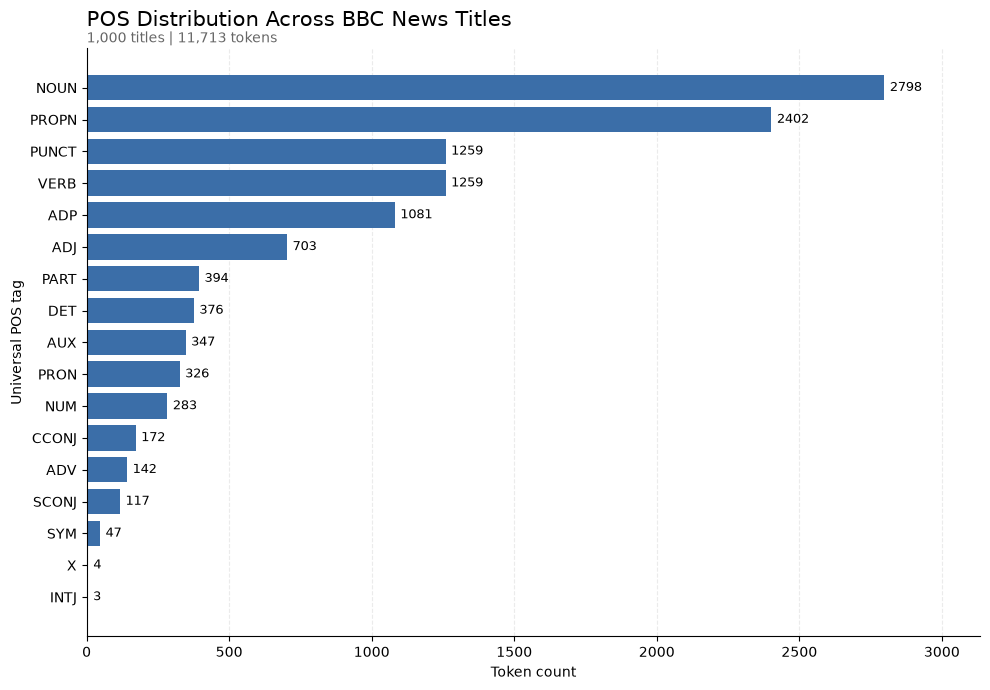

In [20]:
# barh 需要从小到大排序，这样最高频的词性会显示在最上方。
pos_plot_data = pos_statistics.sort_values("Count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(pos_plot_data["POS"], pos_plot_data["Count"], color="#3B6EA8")

ax.set_title("POS Distribution Across BBC News Titles", loc="left", fontsize=15, pad=16)
ax.text(
    0,
    1.01,
    f"{len(titles):,} titles | {len(pos_dataframe):,} tokens",
    transform=ax.transAxes,
    color="#666666",
    fontsize=10,
)
ax.set_xlabel("Token count")
ax.set_ylabel("Universal POS tag")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlim(0, pos_plot_data["Count"].max() * 1.12)

plt.tight_layout()
plt.show()

### 18. 详细 POS Tag 统计

`POS` 是通用词性，`Tag` 是更细的英语词性标签。下表展示出现次数最高的 15 种详细标签。

In [21]:
# 同时按 POS 和 Tag 分组，避免丢失通用词性与详细词性的对应关系。
detailed_pos_statistics = (
    pos_dataframe
    .groupby(["POS", "Tag"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)
detailed_pos_statistics.insert(0, "Rank", range(1, len(detailed_pos_statistics) + 1))
detailed_pos_statistics["Description"] = detailed_pos_statistics["Tag"].map(spacy.explain)

detailed_pos_statistics.head(15)

,Rank,POS,Tag,Count,Description
0,1,PROPN,NNP,2321,"noun, proper singular"
1,2,NOUN,NN,2100,"noun, singular or mass"
2,3,ADP,IN,1025,"conjunction, subordinating or preposition"
3,4,NOUN,NNS,698,"noun, plural"
4,5,ADJ,JJ,657,"adjective (English), other noun-modifier (Chin..."
5,6,PUNCT,:,566,"punctuation mark, colon or ellipsis"
6,7,DET,DT,365,determiner
7,8,VERB,VBZ,317,"verb, 3rd person singular present"
8,9,VERB,VB,312,"verb, base form"
9,10,NUM,CD,283,cardinal number


### 19. NER 实体类型分布统计

将每个标题中的命名实体临时展平，然后按实体类型分组。没有实体的标题不会产生记录，但仍保留在原始 `ner_results_list` 中。

In [22]:
# 从嵌套 NER 结果构建临时表格，一行表示一个实体。
ner_records = [
    {
        "Entity": entity_text,
        "Entity Type": entity_label,
        "Description": entity_description,
    }
    for title_ner_results in ner_results_list
    for entity_text, entity_label, entity_description in title_ner_results
]
ner_dataframe = pd.DataFrame(ner_records)

# first() 取每种实体类型的说明，size() 计算实体数量。
ner_statistics = (
    ner_dataframe
    .groupby("Entity Type", as_index=False)
    .agg(
        Count=("Entity", "size"),
        Description=("Description", "first"),
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)
ner_statistics.insert(0, "Rank", range(1, len(ner_statistics) + 1))
ner_statistics["Share (%)"] = (
    ner_statistics["Count"] / ner_statistics["Count"].sum() * 100
).round(2)

ner_statistics

,Rank,Entity Type,Count,Description,Share (%)
0,1,PERSON,452,"People, including fictional",27.44
1,2,GPE,411,"Countries, cities, states",24.95
2,3,ORG,304,"Companies, agencies, institutions, etc.",18.46
3,4,DATE,107,Absolute or relative dates or periods,6.50
4,5,CARDINAL,103,Numerals that do not fall under another type,6.25
5,6,NORP,92,Nationalities or religious or political groups,5.59
6,7,EVENT,45,"Named hurricanes, battles, wars, sports events...",2.73
7,8,ORDINAL,29,"""first"", ""second"", etc.",1.76
8,9,LOC,24,"Non-GPE locations, mountain ranges, bodies of ...",1.46
9,10,WORK_OF_ART,21,"Titles of books, songs, etc.",1.28


### 20. NER 实体类型分布可视化

图中展示每种命名实体类型的识别数量。

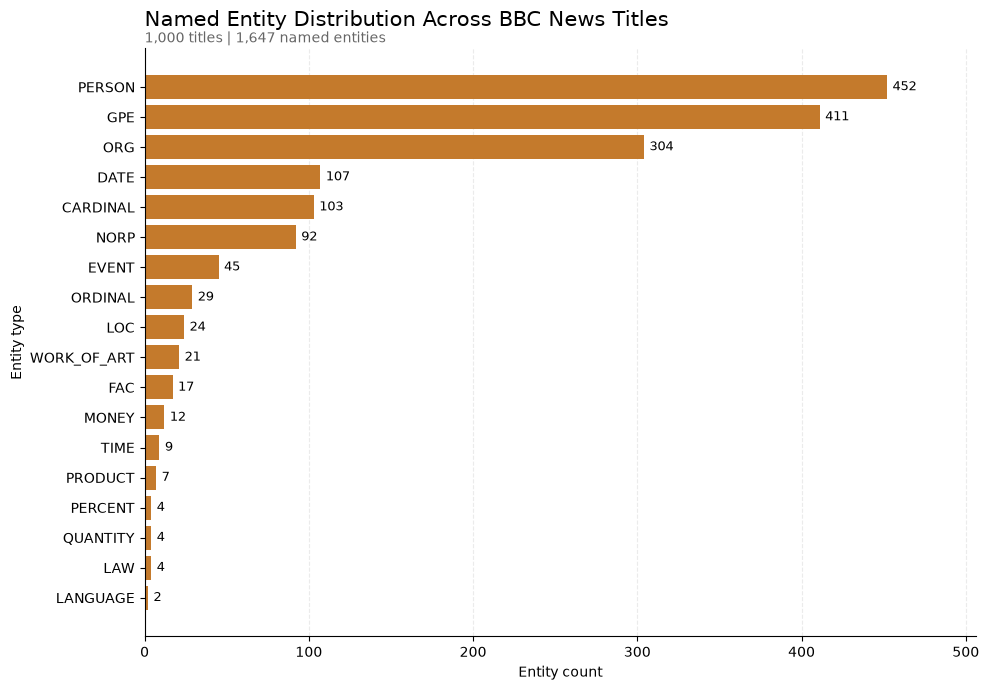

In [23]:
# 使用与 POS 图一致的视觉结构，但用不同颜色区分 NER。
ner_plot_data = ner_statistics.sort_values("Count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    ner_plot_data["Entity Type"],
    ner_plot_data["Count"],
    color="#C47A2C",
)

ax.set_title("Named Entity Distribution Across BBC News Titles", loc="left", fontsize=15, pad=16)
ax.text(
    0,
    1.01,
    f"{len(titles):,} titles | {len(ner_dataframe):,} named entities",
    transform=ax.transAxes,
    color="#666666",
    fontsize=10,
)
ax.set_xlabel("Entity count")
ax.set_ylabel("Entity type")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlim(0, ner_plot_data["Count"].max() * 1.12)

plt.tight_layout()
plt.show()

### 21. 排行榜参数与通用统计函数

将排行榜的可调参数集中放在一处，后续要把前 10 改为前 20，只需修改 `TOP_CONTENT_COUNT`。

`build_content_rankings()` 封装了 POS 和 NER 共用的“过滤、计数、排名、计算占比”流程，避免两段几乎相同的 pandas 代码。

In [24]:
# -------------------------
# 排行榜统一参数
# -------------------------
TOP_CATEGORY_COUNT = 3   # 取 POS / NER 总数排名前几的类别
TOP_CONTENT_COUNT = 10   # 每个类别中展示几条高频内容


def build_content_rankings(
    dataframe,
    category_column,
    content_column,
    top_categories,
    top_n,
    normalize_case=False,
):
    """
    统计指定类别中的高频内容，返回结构统一的排行榜。

    Parameters
    ----------
    dataframe : pandas.DataFrame
        已铺平的 POS 或 NER 数据表。
    category_column : str
        类别列名，例如 ``POS`` 或 ``Entity Type``。
    content_column : str
        要统计频数的内容列，例如 ``Token`` 或 ``Entity``。
    top_categories : list[str]
        需要分别生成排行榜的类别，列表顺序也是最终展示顺序。
    top_n : int
        每个类别保留的最高频内容数量。
    normalize_case : bool, default False
        是否在“仅用于统计的副本”上统一大小写。

    Returns
    -------
    pandas.DataFrame
        包含类别、排名、内容、频数、类别总数和类别内占比。

    Notes
    -----
    该函数先 ``copy()`` 再处理，因此不会改变传入的 DataFrame。
    频数相同时按内容字母顺序排列，保证每次运行都得到确定的排名。
    """
    # 只复制本次统计所需的两列，避免修改原表。
    selected_rows = dataframe.loc[
        dataframe[category_column].isin(top_categories),
        [category_column, content_column],
    ].copy()

    # 去掉内容两端的空白；POS Token 可选择再统一大小写。
    selected_rows["Content"] = selected_rows[content_column].astype(str).str.strip()
    if normalize_case:
        selected_rows["Content"] = selected_rows["Content"].str.casefold()

    # 每一个“类别 + 内容”组合生成一行频数。
    content_counts = (
        selected_rows
        .groupby([category_column, "Content"], as_index=False)
        .size()
        .rename(columns={"size": "Count"})
    )

    # 类别总数用于计算“该内容在本类别中的占比”。
    category_totals = dataframe[category_column].value_counts()
    content_counts["Category Total"] = content_counts[category_column].map(category_totals)

    # 显式构建类别顺序，不依赖 pandas 默认的字母排序。
    category_order = {
        category: order
        for order, category in enumerate(top_categories)
    }
    content_counts["_Category Order"] = content_counts[category_column].map(category_order)
    content_counts = content_counts.sort_values(
        ["_Category Order", "Count", "Content"],
        ascending=[True, False, True],
    )

    # cumcount() 在每个类别内从 0 开始计数，加 1 即得到 1 开始的排名。
    content_counts["Rank"] = (
        content_counts.groupby(category_column, sort=False).cumcount() + 1
    )
    rankings = content_counts.loc[content_counts["Rank"] <= top_n].copy()
    rankings["Share within category (%)"] = (
        rankings["Count"] / rankings["Category Total"] * 100
    ).round(2)

    # 只返回阅读和绘图需要的列，隐藏内部排序辅助列。
    return rankings[
        [
            category_column,
            "Rank",
            "Content",
            "Count",
            "Category Total",
            "Share within category (%)",
        ]
    ].reset_index(drop=True)

### 22. 通用排行榜绘图函数

`plot_content_rankings()` 统一管理三栏水平柱状图的排序、标题、颜色、数值标签和坐标轴样式。POS 和 NER 只需传入自己的表格与文字配置。

In [25]:
def plot_content_rankings(
    rankings,
    category_column,
    categories,
    colors,
    item_name,
    count_label,
    figure_title,
    figure_width=18,
):
    """
    将多个类别的高频内容绘制为并排水平柱状图。

    Parameters
    ----------
    rankings : pandas.DataFrame
        ``build_content_rankings()`` 返回的排行榜表。
    category_column : str
        排行榜中的类别列名。
    categories : list[str]
        需要绘制的类别及其左到右的顺序。
    colors : list[str]
        每个子图对应的颜色，数量必须与 categories 一致。
    item_name : str
        标题中的内容名称，例如 ``Tokens`` 或 ``Entities``。
    count_label : str
        x 轴的数量单位。
    figure_title : str
        整张图的总标题。
    figure_width : int | float, default 18
        整张图的宽度，NER 名称较长时可适当增大。

    Returns
    -------
    tuple
        Matplotlib 的 ``(figure, axes)``，便于后续继续调整或保存。
    """
    if len(categories) != len(colors):
        raise ValueError("categories 和 colors 的数量必须相同。")

    figure, axes = plt.subplots(
        1,
        len(categories),
        figsize=(figure_width, 6),
        constrained_layout=True,
    )

    # 兼容只绘制一个类别的情况：此时 Matplotlib 返回单个 Axes 而不是数组。
    axes_list = [axes] if len(categories) == 1 else axes

    for axis, category, color in zip(axes_list, categories, colors):
        # barh 从下向上绘制，因此先升序排列，让第 1 名显示在顶部。
        category_data = (
            rankings.loc[rankings[category_column] == category]
            .sort_values("Count", ascending=True)
        )
        bars = axis.barh(category_data["Content"], category_data["Count"], color=color)

        axis.set_title(
            f"{category}: Top {len(category_data)} {item_name}",
            loc="left",
            fontsize=13,
        )
        axis.set_xlabel(count_label)
        axis.set_ylabel("")
        axis.grid(axis="x", linestyle="--", alpha=0.25)
        axis.set_axisbelow(True)
        axis.spines[["top", "right"]].set_visible(False)
        axis.bar_label(bars, padding=3, fontsize=9)

        # 从 0 开始确保柱长如实表示数量；右侧留白用于显示数值标签。
        maximum_count = category_data["Count"].max()
        axis.set_xlim(0, maximum_count * 1.20)

    figure.suptitle(figure_title, fontsize=16)
    plt.show()
    return figure, axes

### 23. POS 前 3 类高频 Token 排行榜

先从 `pos_statistics` 取总数前 3 的 POS 类别，再调用通用函数生成每类前 10 名。

POS 排行榜仅在统计副本上统一大小写，因此 `The` 和 `the` 会合并计数，但原始 Token 不会改变。

In [26]:
# POS 总统计表已按 Count 降序排列，head(3) 即为前 3 类。
top_pos_categories = pos_statistics.head(TOP_CATEGORY_COUNT)["POS"].tolist()

pos_top_content_rankings = build_content_rankings(
    dataframe=pos_dataframe,
    category_column="POS",
    content_column="Token",
    top_categories=top_pos_categories,
    top_n=TOP_CONTENT_COUNT,
    normalize_case=True,
)

pos_top_content_rankings

,POS,Rank,Content,Count,Category Total,Share within category (%)
0,NOUN,1,war,35,2798,1.25
1,NOUN,2,police,18,2798,0.64
2,NOUN,3,win,18,2798,0.64
3,NOUN,4,energy,17,2798,0.61
4,NOUN,5,week,17,2798,0.61
5,NOUN,6,women,17,2798,0.61
6,NOUN,7,cost,16,2798,0.57
7,NOUN,8,living,15,2798,0.54
8,NOUN,9,record,15,2798,0.54
9,NOUN,10,year,15,2798,0.54


### 24. POS 高频 Token 排行榜可视化

三张子图使用同一蓝色系的不同色阶，并直接标出频数，无需额外图例。

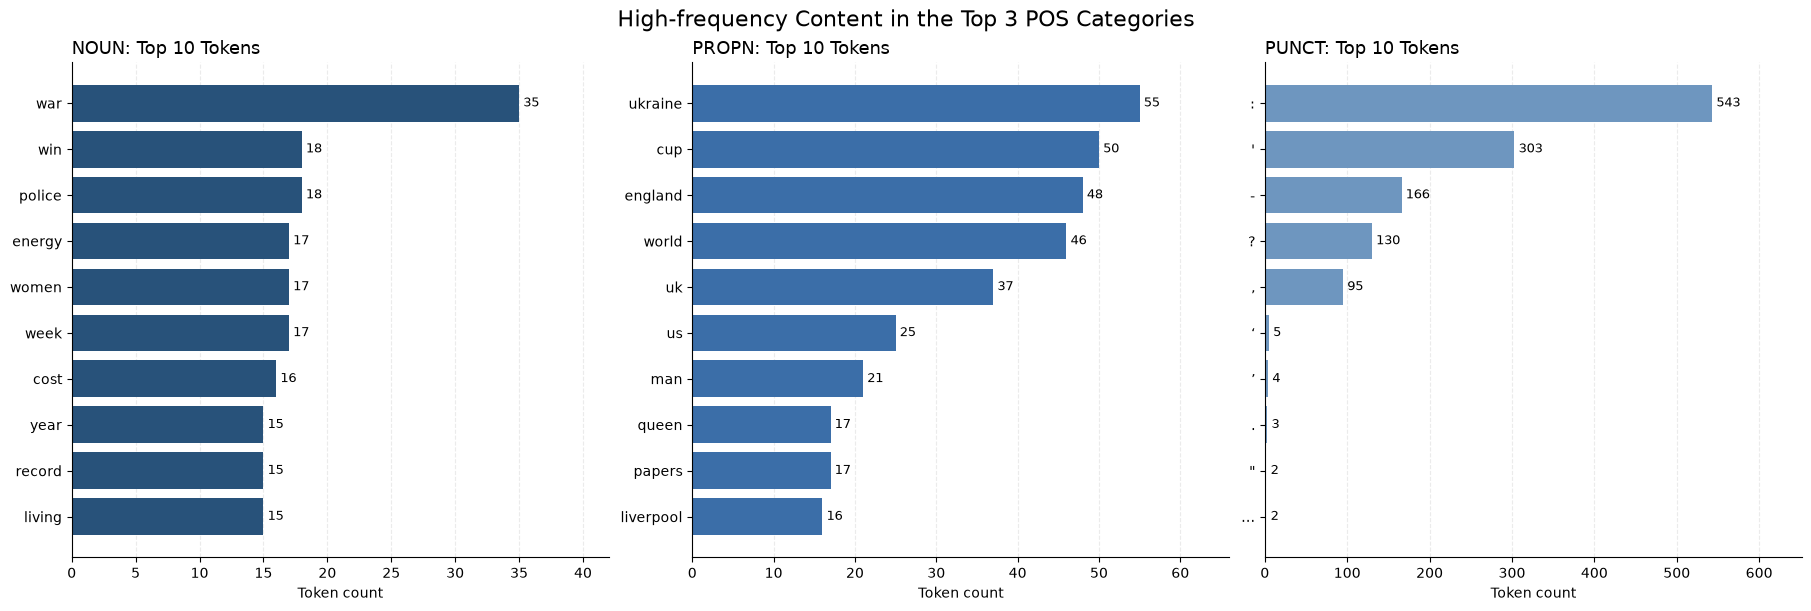

In [27]:
# 颜色列表与 top_pos_categories 按位置一一对应。
POS_RANKING_COLORS = ["#28527A", "#3B6EA8", "#6E96BF"]

pos_ranking_figure, pos_ranking_axes = plot_content_rankings(
    rankings=pos_top_content_rankings,
    category_column="POS",
    categories=top_pos_categories,
    colors=POS_RANKING_COLORS,
    item_name="Tokens",
    count_label="Token count",
    figure_title="High-frequency Content in the Top 3 POS Categories",
    figure_width=18,
)

### 25. NER 前 3 类高频实体排行榜

与 POS 使用同一个统计函数，但 NER 保留 spaCy 识别到的原始大小写，便于阅读人名、地名和机构名。

In [28]:
top_ner_categories = ner_statistics.head(TOP_CATEGORY_COUNT)["Entity Type"].tolist()

ner_top_content_rankings = build_content_rankings(
    dataframe=ner_dataframe,
    category_column="Entity Type",
    content_column="Entity",
    top_categories=top_ner_categories,
    top_n=TOP_CONTENT_COUNT,
    normalize_case=False,
)

ner_top_content_rankings

,Entity Type,Rank,Content,Count,Category Total,Share within category (%)
0,PERSON,1,Putin,8,452,1.77
1,PERSON,2,Boris Johnson,6,452,1.33
2,PERSON,3,Liz Truss,6,452,1.33
3,PERSON,4,Queen,6,452,1.33
4,PERSON,5,Covid,5,452,1.11
5,PERSON,6,Harry,5,452,1.11
6,PERSON,7,Rishi Sunak,5,452,1.11
7,PERSON,8,Emma Raducanu,4,452,0.88
8,PERSON,9,Jurgen Klopp,4,452,0.88
9,PERSON,10,Macron,4,452,0.88


### 26. NER 高频实体排行榜可视化

NER 使用与前面实体分布图一致的橙色系。`figure_width=19` 给较长的实体名称留出更多空间。

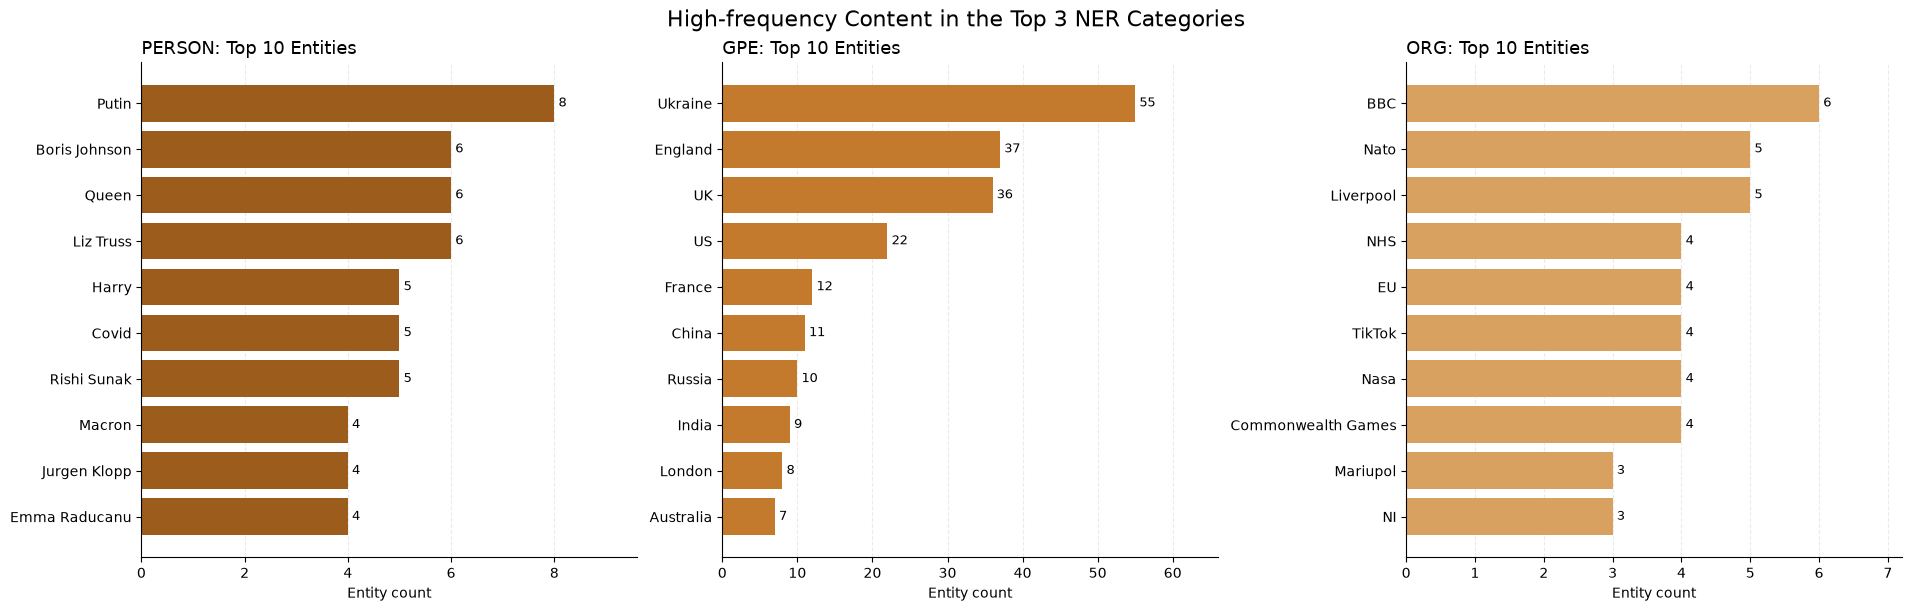

In [29]:
NER_RANKING_COLORS = ["#9C5C1B", "#C47A2C", "#D9A15F"]

ner_ranking_figure, ner_ranking_axes = plot_content_rankings(
    rankings=ner_top_content_rankings,
    category_column="Entity Type",
    categories=top_ner_categories,
    colors=NER_RANKING_COLORS,
    item_name="Entities",
    count_label="Entity count",
    figure_title="High-frequency Content in the Top 3 NER Categories",
    figure_width=19,
)

### 27. 统计与排行榜结果检查

检查统计表总数是否与嵌套列表中的原始 POS/NER 结果一致，检查前 3 类排行榜的结构，并再次确认源 DataFrame 和 CSV 文件没有变化。

In [30]:
# 嵌套列表中的总记录数应与临时 DataFrame、统计表的总数一致。
expected_pos_count = sum(len(title_results) for title_results in pos_results_list)
expected_ner_count = sum(len(title_results) for title_results in ner_results_list)

assert len(pos_dataframe) == expected_pos_count
assert pos_statistics["Count"].sum() == expected_pos_count
assert len(ner_dataframe) == expected_ner_count
assert ner_statistics["Count"].sum() == expected_ner_count

# 由于占比显示时保留两位小数，允许极小的四舍五入误差。
assert abs(pos_statistics["Share (%)"].sum() - 100) < 0.1
assert abs(ner_statistics["Share (%)"].sum() - 100) < 0.1

# 再次检查源数据：只新增了统计变量，没有改写 bbc_news 或 CSV。
pd.testing.assert_frame_equal(bbc_news, bbc_news_snapshot)
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source_hash_before

print("✓ POS 统计总数与原始结果一致：", f"{expected_pos_count:,}")
print("✓ NER 统计总数与原始结果一致：", f"{expected_ner_count:,}")
print("✓ bbc_news DataFrame 和 bbc_news.csv 均未改变。")

# 前 3 类应各有 10 条排行榜记录，每类的 Rank 应恰好为 1~10。
assert top_pos_categories == pos_statistics.head(TOP_CATEGORY_COUNT)["POS"].tolist()
assert top_ner_categories == ner_statistics.head(TOP_CATEGORY_COUNT)["Entity Type"].tolist()
for category in top_pos_categories:
    category_ranks = pos_top_content_rankings.loc[
        pos_top_content_rankings["POS"] == category, "Rank"
    ].tolist()
    assert category_ranks == list(range(1, TOP_CONTENT_COUNT + 1))
for category in top_ner_categories:
    category_ranks = ner_top_content_rankings.loc[
        ner_top_content_rankings["Entity Type"] == category, "Rank"
    ].tolist()
    assert category_ranks == list(range(1, TOP_CONTENT_COUNT + 1))

assert pos_top_content_rankings["Count"].sum() <= expected_pos_count
assert ner_top_content_rankings["Count"].sum() <= expected_ner_count
print("✓ POS 前 3 类高频 Token 排行榜检查通过：", top_pos_categories)
print("✓ NER 前 3 类高频实体排行榜检查通过：", top_ner_categories)

# 通用函数应返回统一、易于后续处理的列结构。
expected_pos_ranking_columns = [
    "POS", "Rank", "Content", "Count", "Category Total", "Share within category (%)"
]
expected_ner_ranking_columns = [
    "Entity Type", "Rank", "Content", "Count", "Category Total", "Share within category (%)"
]
assert pos_top_content_rankings.columns.tolist() == expected_pos_ranking_columns
assert ner_top_content_rankings.columns.tolist() == expected_ner_ranking_columns

# 每个类别内都应按 Rank 递增，同时 Count 不应随排名下降而增加。
for rankings, category_column, categories in [
    (pos_top_content_rankings, "POS", top_pos_categories),
    (ner_top_content_rankings, "Entity Type", top_ner_categories),
]:
    for category in categories:
        category_ranking = rankings.loc[rankings[category_column] == category]
        assert category_ranking["Rank"].tolist() == list(range(1, TOP_CONTENT_COUNT + 1))
        assert category_ranking["Count"].is_monotonic_decreasing

print("✓ 通用排行榜函数的列结构、排名顺序和频数顺序检查通过。")

✓ POS 统计总数与原始结果一致： 11,713
✓ NER 统计总数与原始结果一致： 1,647
✓ bbc_news DataFrame 和 bbc_news.csv 均未改变。
✓ POS 前 3 类高频 Token 排行榜检查通过： ['NOUN', 'PROPN', 'PUNCT']
✓ NER 前 3 类高频实体排行榜检查通过： ['PERSON', 'GPE', 'ORG']
✓ 通用排行榜函数的列结构、排名顺序和频数顺序检查通过。


## Next Steps

POS 和 NER 的处理、总体统计、高频排行榜及可视化已完成。排行榜的统计与绘图逻辑已提取为可复用函数，后续可通过修改集中参数调整展示范围。

下一步可以将高频实体回溯到具体新闻标题，或比较不同新闻类别的 POS/NER 特征。